# The lab work task
Solve the regression problem for the one of the presented datasets using the same steps into your work.
To get you variant: (your_num % 9), where your_num is your number in the group list.

In addition to presented in the example methods consider other ML methods like Support Vector Machine, Gradient Boosting Regression, Bayesian Ridge Regression.

Present your work in the Jupyter Notebook variant

P.s. in provided data sources you can find examples of solving this problem, but be ready to explain the code and results.


## Chosen dataset
[Gold Price Prediction](https://www.kaggle.com/datasets/franciscogcc/financial-data)


In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data/financial_regression.csv")

df.head()

,date,sp500 open,sp500 high,sp500 low,sp500 close,sp500 volume,sp500 high-low,nasdaq open,nasdaq high,nasdaq low,...,palladium high,palladium low,palladium close,palladium volume,palladium high-low,gold open,gold high,gold low,gold close,gold volume
0,2010-01-14,114.49,115.14,114.42,114.93,115646960.0,0.72,46.26,46.520,46.22,...,45.02,43.86,44.84,364528.0,1.16,111.51,112.37,110.79,112.03,18305238.0
1,2010-01-15,114.73,114.84,113.20,113.64,212252769.0,1.64,46.46,46.550,45.65,...,45.76,44.40,45.76,442210.0,1.36,111.35,112.01,110.38,110.86,18000724.0
2,2010-01-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-19,113.62,115.13,113.59,115.06,138671890.0,1.54,45.96,46.640,45.95,...,47.08,45.70,46.94,629150.0,1.38,110.95,111.75,110.83,111.52,10467927.0
4,2010-01-20,114.28,114.45,112.98,113.89,216330645.0,1.47,46.27,46.604,45.43,...,47.31,45.17,47.05,643198.0,2.14,109.97,110.05,108.46,108.94,17534231.0


In [3]:
df.columns

Index(['date', 'sp500 open', 'sp500 high', 'sp500 low', 'sp500 close',
       'sp500 volume', 'sp500 high-low', 'nasdaq open', 'nasdaq high',
       'nasdaq low', 'nasdaq close', 'nasdaq volume', 'nasdaq high-low',
       'us_rates_%', 'CPI', 'usd_chf', 'eur_usd', 'GDP', 'silver open',
       'silver high', 'silver low', 'silver close', 'silver volume',
       'silver high-low', 'oil open', 'oil high', 'oil low', 'oil close',
       'oil volume', 'oil high-low', 'platinum open', 'platinum high',
       'platinum low', 'platinum close', 'platinum volume',
       'platinum high-low', 'palladium open', 'palladium high',
       'palladium low', 'palladium close', 'palladium volume',
       'palladium high-low', 'gold open', 'gold high', 'gold low',
       'gold close', 'gold volume'],
      dtype='object')

In [4]:
selected_columns = ['date', 'sp500 open', 'sp500 high', 'sp500 low', 'sp500 close',
                    'sp500 volume', 'sp500 high-low', 'nasdaq open', 'nasdaq high',
                    'nasdaq low', 'nasdaq close', 'nasdaq volume', 'nasdaq high-low',
                    'usd_chf', 'eur_usd', 'silver open',
                    'silver high', 'silver low', 'silver close', 'silver volume',
                    'silver high-low', 'oil open', 'oil high', 'oil low', 'oil close',
                    'oil volume', 'oil high-low', 'platinum open', 'platinum high',
                    'platinum low', 'platinum close', 'platinum volume',
                    'platinum high-low', 'palladium open', 'palladium high',
                    'palladium low', 'palladium close', 'palladium volume',
                    'palladium high-low', 'gold open', 'gold high', 'gold low',
                    'gold close', 'gold volume']
df_train = df[selected_columns]

In [5]:
print(df_train.isnull().sum())

date                    0
sp500 open            185
sp500 high            185
sp500 low             185
sp500 close           185
sp500 volume          185
sp500 high-low        185
nasdaq open           185
nasdaq high           185
nasdaq low            185
nasdaq close          185
nasdaq volume         185
nasdaq high-low       185
usd_chf               210
eur_usd               210
silver open           185
silver high           185
silver low            185
silver close          185
silver volume         185
silver high-low       185
oil open              185
oil high              185
oil low               185
oil close             185
oil volume            185
oil high-low          185
platinum open         185
platinum high         185
platinum low          185
platinum close        185
platinum volume       185
platinum high-low     185
palladium open        185
palladium high        185
palladium low         185
palladium close       185
palladium volume      185
palladium hi

In [6]:
df_train.duplicated().sum()

np.int64(0)

In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3904 entries, 0 to 3903
Data columns (total 44 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                3904 non-null   object 
 1   sp500 open          3719 non-null   float64
 2   sp500 high          3719 non-null   float64
 3   sp500 low           3719 non-null   float64
 4   sp500 close         3719 non-null   float64
 5   sp500 volume        3719 non-null   float64
 6   sp500 high-low      3719 non-null   float64
 7   nasdaq open         3719 non-null   float64
 8   nasdaq high         3719 non-null   float64
 9   nasdaq low          3719 non-null   float64
 10  nasdaq close        3719 non-null   float64
 11  nasdaq volume       3719 non-null   float64
 12  nasdaq high-low     3719 non-null   float64
 13  usd_chf             3694 non-null   float64
 14  eur_usd             3694 non-null   float64
 15  silver open         3719 non-null   float64
 16  silver

In [8]:
cat_val = df_train.select_dtypes(include=['object']).columns
num_val = df_train.select_dtypes(include=['int', "float"]).columns

print(cat_val, '\n', num_val)

Index(['date'], dtype='object') 
 Index(['sp500 open', 'sp500 high', 'sp500 low', 'sp500 close', 'sp500 volume',
       'sp500 high-low', 'nasdaq open', 'nasdaq high', 'nasdaq low',
       'nasdaq close', 'nasdaq volume', 'nasdaq high-low', 'usd_chf',
       'eur_usd', 'silver open', 'silver high', 'silver low', 'silver close',
       'silver volume', 'silver high-low', 'oil open', 'oil high', 'oil low',
       'oil close', 'oil volume', 'oil high-low', 'platinum open',
       'platinum high', 'platinum low', 'platinum close', 'platinum volume',
       'platinum high-low', 'palladium open', 'palladium high',
       'palladium low', 'palladium close', 'palladium volume',
       'palladium high-low', 'gold open', 'gold high', 'gold low',
       'gold close', 'gold volume'],
      dtype='object')


In [9]:
df_train = df_train.dropna()

df_train.isnull().sum()

date                  0
sp500 open            0
sp500 high            0
sp500 low             0
sp500 close           0
sp500 volume          0
sp500 high-low        0
nasdaq open           0
nasdaq high           0
nasdaq low            0
nasdaq close          0
nasdaq volume         0
nasdaq high-low       0
usd_chf               0
eur_usd               0
silver open           0
silver high           0
silver low            0
silver close          0
silver volume         0
silver high-low       0
oil open              0
oil high              0
oil low               0
oil close             0
oil volume            0
oil high-low          0
platinum open         0
platinum high         0
platinum low          0
platinum close        0
platinum volume       0
platinum high-low     0
palladium open        0
palladium high        0
palladium low         0
palladium close       0
palladium volume      0
palladium high-low    0
gold open             0
gold high             0
gold low        

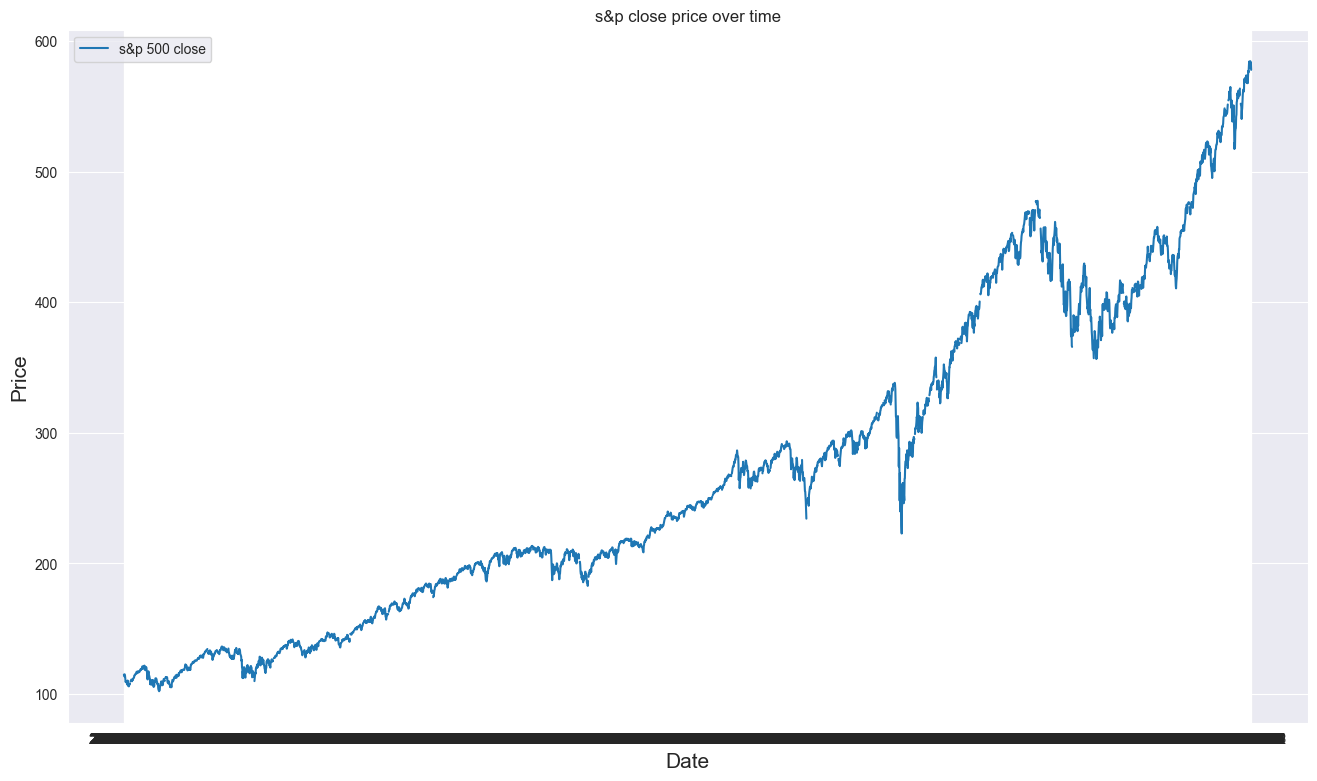

In [11]:
plt.figure(figsize=(16, 9))
plt.plot(df['date'], df['sp500 close'], label='s&p 500 close')
plt.title('s&p close price over time')
plt.xlabel('Date', fontsize=15)
plt.ylabel('Price', fontsize=15)
plt.legend()
plt.show()

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

df_train['date'] = pd.to_datetime(df_train['date'])
df_2023 = df_train[df_train['date'] >= pd.Timestamp('2023-01-01')]

target = 'gold close'
features = [col for col in df_2023.columns if col not in ['date', target]]

train, test = train_test_split(df_2023, test_size=0.2, shuffle=False)

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 0.42
R² Score: 0.9977


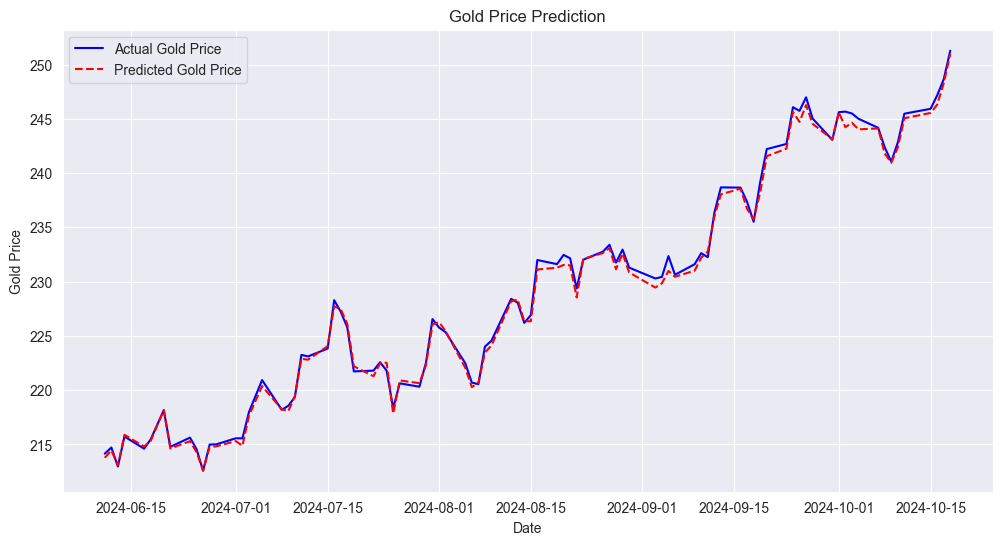

In [20]:
plt.figure(figsize=(12,6))
plt.plot(test['date'], y_test, label="Actual Gold Price", color='blue')
plt.plot(test['date'], y_pred, label="Predicted Gold Price", color='red', linestyle='dashed')
plt.title("Gold Price Prediction")
plt.xlabel("Date")
plt.ylabel("Gold Price")
plt.legend()
plt.show()